In [1]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import dill
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

burn_in = 500

### Load in data from Shekhar fitted with AR(1)

In [ ]:
file_name = './Shekhar_simulations.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves

In [3]:
num_subjects = posterior_samples_a.shape[1]

all_r = []
all_rmse = []

posterior_samples_states_mean = jnp.mean(posterior_samples_states[burn_in:,:,:], axis=0) 

for subject in range(num_subjects):
    r, _ = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
    rmse = jnp.sqrt(jnp.mean((true_states[subject]-posterior_samples_states_mean[subject])**2))

    all_r.append(r)
    all_rmse.append(rmse)

### Load in data from Shekhar fitted with random walk

In [ ]:
file_name = './Shekhar_simulations_random_walk.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves

In [5]:
posterior_samples_states_mean = jnp.mean(posterior_samples_states[burn_in:,:,:], axis=0) 

for subject in range(num_subjects):
    r, _ = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
    rmse = jnp.sqrt(jnp.mean((true_states[subject]-posterior_samples_states_mean[subject])**2))

    all_r.append(r)
    all_rmse.append(rmse)

all_rmse = jnp.stack(all_rmse)

In [6]:
data = pd.DataFrame({
    "subject": np.tile(np.arange(num_subjects), 2),
    "condition": np.repeat(["a estimated", "a = .9995"], num_subjects),
    "correlation": all_r,
    "rmse": all_rmse,
})

In [8]:
ar1_correlation = data['correlation'][0:20]
randomwalk_correlation = data['correlation'][20:40]

ar1_rmse = data['rmse'][0:20]
randomwalk_rmse = data['rmse'][20:40]

In [9]:
t_cor, p_cor = stats.ttest_rel(ar1_correlation, randomwalk_correlation)

print(f"T-statistic correlation: {t_cor:.4f}")
print(f"P-value correlation: {p_cor:.4f}")

T-statistic correlation: 7.3680
P-value correlation: 0.0000


In [10]:
t_rmse, p_rmse = stats.ttest_rel(ar1_rmse, randomwalk_rmse)

print(f"T-statistic rmse: {t_rmse:.4f}")
print(f"P-value rmse: {p_rmse:.4f}")

T-statistic rmse: -8.2986
P-value rmse: 0.0000


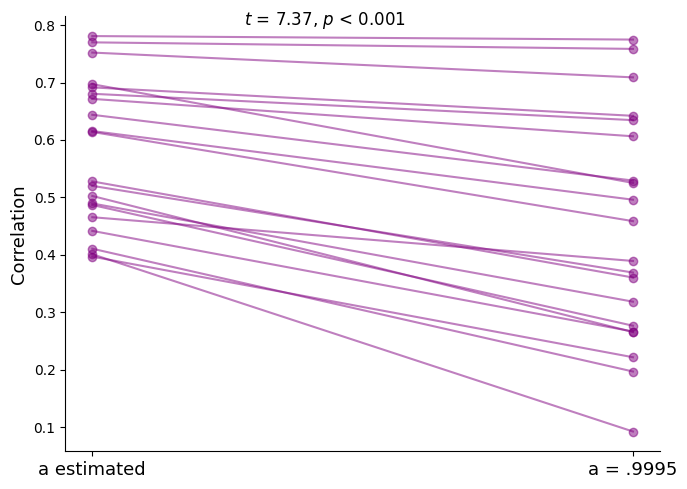

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

for subject_id in data["subject"].unique():
    subject_data = data[data["subject"] == subject_id]
    ax.plot(
        subject_data["condition"], 
        subject_data["correlation"], 
        marker="o", 
        linestyle="-", 
        alpha=0.5,
        color="purple"
    )
    
ax.tick_params(axis='x', labelsize=13)
ax.set_ylabel("Correlation", size=13)
ax.annotate(
    f'$t$ = {t_cor:.2f}, $p$ < 0.001',
    xy=(0.3, 0.98),
    xycoords='axes fraction',
    fontsize=12
)
plt.tight_layout()
sns.despine()
plt.savefig("shekhar_ar_rw_correlation.png", dpi=600)

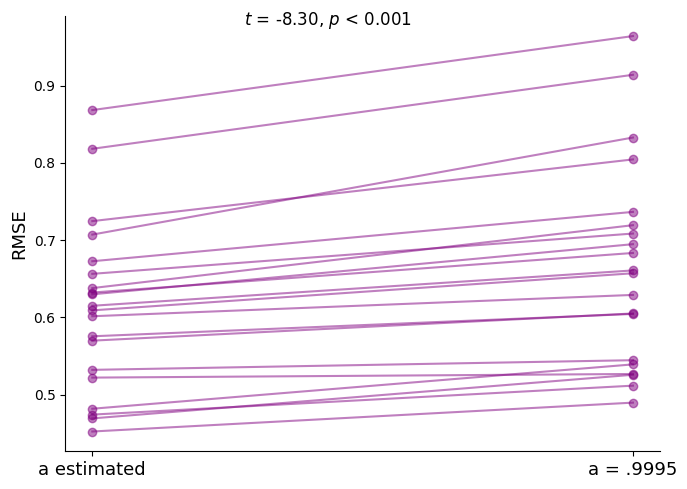

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

for subject_id in data["subject"].unique():
    subject_data = data[data["subject"] == subject_id]
    ax.plot(
        subject_data["condition"], 
        subject_data["rmse"], 
        marker="o", 
        linestyle="-", 
        alpha=0.5,
        color="purple"
    )
    
ax.tick_params(axis='x', labelsize=13)
ax.set_ylabel("RMSE", size=13)
ax.annotate(
    f'$t$ = {t_rmse:.2f}, $p$ < 0.001',
    xy=(0.3, 0.98),
    xycoords='axes fraction',
    fontsize=12
)
plt.tight_layout()
sns.despine()
plt.savefig("shekhar_ar_rw_rmse.png", dpi=600)